## Customer Churn

"Churn Rate" is a business term describing the rate at which customers leave or stop paying for a service. It's a critical number for any subscription business, since acquiring a new customer is usually far more expensive than keeping an existing one.

Understanding what keeps customers engaged is therefore valuable: it's the foundation for building retention strategies and deciding which customers a support team should call first. This notebook walks through a simple case study on a mobile carrier's customer data, showing how a handful of standard classifiers can be used to predict churn.

Reducing churn usually means running a retention team that calls down a list of at-risk customers. Organizing that team well requires knowing who is actually at risk, since spending time and discounts on a customer who was never going to leave is just wasted budget. That's the problem this notebook tries to solve: separate the customers who are likely to churn from the ones who aren't, using the data below.

### The Dataset

Each row is a mobile subscriber. The columns cover demographics (`college`, `income`, `house`), billing/usage behaviour (`overage`, `leftover`, `init_payment`, `over_15min`, `call_duration`), and self-reported attitude (`satisfaction`, `usage_level`, `change_plan`). `brand_churn` is the label: 1 if the customer left, 0 otherwise.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression as LR
from sklearn.tree import DecisionTreeClassifier as DT
from sklearn.ensemble import RandomForestClassifier as RF
from sklearn.ensemble import GradientBoostingClassifier as GBC

%matplotlib inline

RANDOM_STATE = 42

In [2]:
churn_df = pd.read_csv('data/mobile_customers.csv')
col_names = churn_df.columns.tolist()

print("Column names:")
print(col_names)

print("\nSample data:")
churn_df.head(6)

Column names:
['id', 'college', 'income', 'overage', 'leftover', 'house', 'init_payment', 'over_15min', 'call_duration', 'satisfaction', 'usage_level', 'change_plan', 'brand_churn']

Sample data:


,id,college,income,overage,leftover,house,init_payment,over_15min,call_duration,satisfaction,usage_level,change_plan,brand_churn
0,2,1.0,36147,0,13,800586.0,244,0,6,unsat,little,considering,0
1,4,0.0,120070,38,33,788235.0,780,3,2,unsat,very_high,considering,1
2,5,NaN,29215,208,85,224784.0,241,21,1,very_unsat,little,never_thought,0
3,6,NaN,133728,64,48,632969.0,626,3,2,unsat,high,no,0
4,8,NaN,84744,0,20,688098.0,357,0,5,very_unsat,little,considering,0
5,9,0.0,38171,0,7,274218.0,190,0,5,very_sat,little,actively_looking_into_it,0


`leftover` comes in as a string column -- one row has `"0,000001"`, written with a comma instead of a decimal point, which is enough to make pandas treat the whole column as text. We fix that before anything else.

In [3]:
churn_df["leftover"] = churn_df["leftover"].str.replace(",", ".", regex=False).astype(float)
churn_df.dtypes

id                 int64
college          float64
income             int64
overage            int64
leftover         float64
house            float64
init_payment       int64
over_15min         int64
call_duration      int64
satisfaction         str
usage_level          str
change_plan          str
brand_churn        int64
dtype: object

`college` is missing for about 39% of rows and `satisfaction` for about 5%. Dropping those rows would throw away close to half the dataset, so instead we fill them in: `college` and `satisfaction` with their most common value, `house` (missing for ~1%) with its median. We also keep a flag for the rows where `college` was missing, in case that absence is itself informative.

In [4]:
churn_df["college_missing"] = churn_df["college"].isna().astype(int)
churn_df["college"] = churn_df["college"].fillna(churn_df["college"].mode()[0])
churn_df["house"] = churn_df["house"].fillna(churn_df["house"].median())
churn_df["satisfaction"] = churn_df["satisfaction"].fillna(churn_df["satisfaction"].mode()[0])

churn_df.isna().sum().sum()

np.int64(0)

We'll keep the feature space close to what's already in the table. `id` is dropped since it's just a row identifier. `satisfaction`, `usage_level` and `change_plan` are text categories with a natural order (`very_unsat` < `unsat` < ... < `very_sat`, and so on), so instead of a plain label encoder -- which would sort them alphabetically and scramble that order -- we map each one to an integer by hand.

In [5]:
# Isolate target data
churn_result = churn_df['brand_churn']
y = np.where(churn_result == 1, 1, 0)

In [6]:
# We don't need this column
to_drop = ['id', 'brand_churn']
churn_feat_space = churn_df.drop(to_drop, axis=1)

In [7]:
satisfaction_order = {"very_unsat": 0, "unsat": 1, "avg": 2, "sat": 3, "very_sat": 4}
usage_level_order = {"very_little": 0, "little": 1, "avg": 2, "high": 3, "very_high": 4}
change_plan_order = {"never_thought": 0, "no": 1, "perhaps": 2, "considering": 3, "actively_looking_into_it": 4}

churn_feat_space['satisfaction'] = churn_feat_space['satisfaction'].map(satisfaction_order)
churn_feat_space['usage_level'] = churn_feat_space['usage_level'].map(usage_level_order)
churn_feat_space['change_plan'] = churn_feat_space['change_plan'].map(change_plan_order)

In [8]:
# Pull out features for future use
features = churn_feat_space.columns
print(features)

Index(['college', 'income', 'overage', 'leftover', 'house', 'init_payment',
       'over_15min', 'call_duration', 'satisfaction', 'usage_level',
       'change_plan', 'college_missing'],
      dtype='str')


In [9]:
X = churn_feat_space.values.astype(np.float64)

# This is important
scaler = StandardScaler()
X = scaler.fit_transform(X)

print("Feature space holds %d observations and %d features" % X.shape)
print("Unique target labels:", np.unique(y))

Feature space holds 17799 observations and 12 features
Unique target labels: [0 1]


One side note: `income` and `house` naturally live on a much bigger scale than something like `over_15min`, even though that doesn't make them a hundred times more important. `StandardScaler` puts every feature on roughly the same footing so that the classifiers below don't end up quietly favouring whichever column happens to have the biggest raw numbers.

We now have a feature matrix `X` and a target vector `y`. On to the predictions.

### How good is your model?

Cross validation is used throughout this notebook so that every prediction is made on data the model hasn't seen. The data is split into folds, a model is trained on all but one fold and used to predict the held-out fold, and this is repeated so that every row eventually gets a prediction from a model that never trained on it.

In [10]:
def run_cv(X, y, clf_class, **kwargs):
    kf = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    y_pred = y.copy()
    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train = y[train_index]
        clf = clf_class(**kwargs)
        clf.fit(X_train, y_train)
        y_pred[test_index] = clf.predict(X_test)
    return y_pred

Let's compare four fairly different classifiers: logistic regression, a single decision tree, random forest, and gradient boosting. Nothing fancy yet, just cross-validated accuracy.

In [11]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

print("Logistic Regression:")
print("%.3f" % accuracy(y, run_cv(X, y, LR, max_iter=1000)))
print("Decision Tree:")
print("%.3f" % accuracy(y, run_cv(X, y, DT, max_depth=6, random_state=RANDOM_STATE)))
print("Random Forest:")
print("%.3f" % accuracy(y, run_cv(X, y, RF, n_estimators=200, max_depth=8, random_state=RANDOM_STATE)))
print("Gradient Boosting Classifier:")
print("%.3f" % accuracy(y, run_cv(X, y, GBC, random_state=RANDOM_STATE)))

Logistic Regression:
0.641
Decision Tree:


0.695
Random Forest:


0.702
Gradient Boosting Classifier:


0.699


The three tree-based models land close together, all a good few points ahead of logistic regression -- not surprising given how much of the signal in this data looks non-linear.

### Precision and recall

Accuracy treats every mistake the same, but the mistakes aren't equally costly here. Predicting a customer will churn when they don't is a wasted retention call. Predicting a customer will stay when they're actually about to leave is the expensive mistake -- that's a customer walking out the door with nobody having tried to stop them.

A confusion matrix is just a table of predicted class against actual class, and it's the easiest way to see both kinds of mistakes at once.

Logistic Regression
[[6005 3015]
 [3382 5397]]


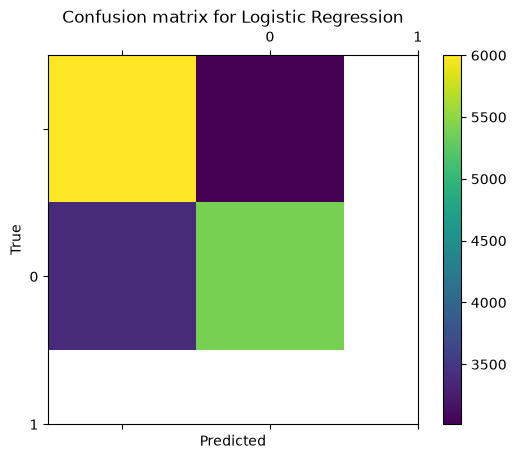

Decision Tree
[[6027 2993]
 [2437 6342]]


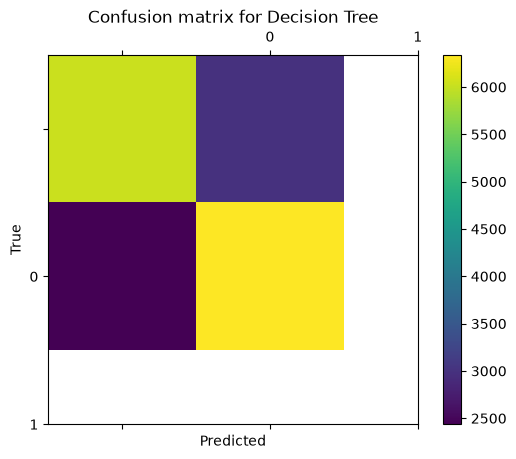

Random Forest
[[6386 2634]
 [2669 6110]]


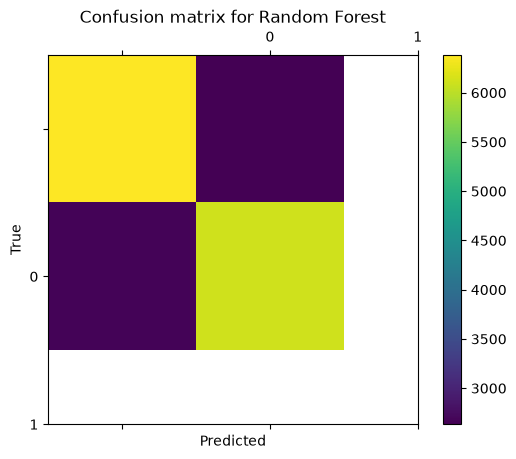

Gradient Boosting Classifier
[[6063 2957]
 [2404 6375]]


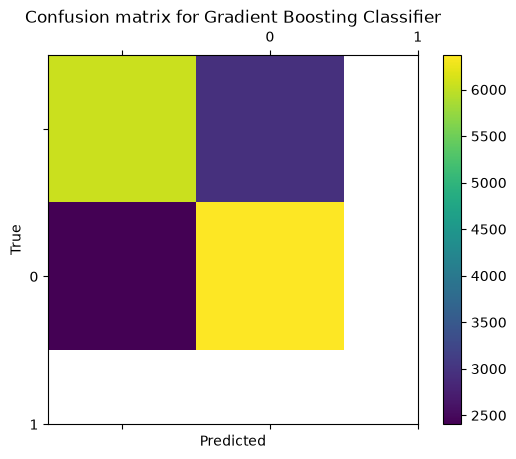

In [12]:
from sklearn.metrics import confusion_matrix

def draw_confusion_matrices(confusion_matrices, class_names):
    class_names = class_names.tolist()
    for name, cm in confusion_matrices:
        print(name)
        print(cm)

        fig = plt.figure()
        ax = fig.add_subplot(111)
        cax = ax.matshow(cm)
        plt.title('Confusion matrix for %s' % name)
        fig.colorbar(cax)
        ax.set_xticks(range(len(class_names) + 1))
        ax.set_yticks(range(len(class_names) + 1))
        ax.set_xticklabels([''] + class_names)
        ax.set_yticklabels([''] + class_names)
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.show()

class_names = np.unique(y)

confusion_matrices = [
    ("Logistic Regression", confusion_matrix(y, run_cv(X, y, LR, max_iter=1000))),
    ("Decision Tree", confusion_matrix(y, run_cv(X, y, DT, max_depth=6, random_state=RANDOM_STATE))),
    ("Random Forest", confusion_matrix(y, run_cv(X, y, RF, n_estimators=200, max_depth=8, random_state=RANDOM_STATE))),
    ("Gradient Boosting Classifier", confusion_matrix(y, run_cv(X, y, GBC, random_state=RANDOM_STATE))),
]

draw_confusion_matrices(confusion_matrices, class_names)

### ROC plots & AUC

Another useful way to look at a classifier is a ROC curve: true positive rate against false positive rate as the decision threshold is swept from 0 to 1. A classifier that's just guessing traces the diagonal, with an area under the curve (AUC) of 0.5 -- anything worth using should sit above that line.

Logistic Regression:


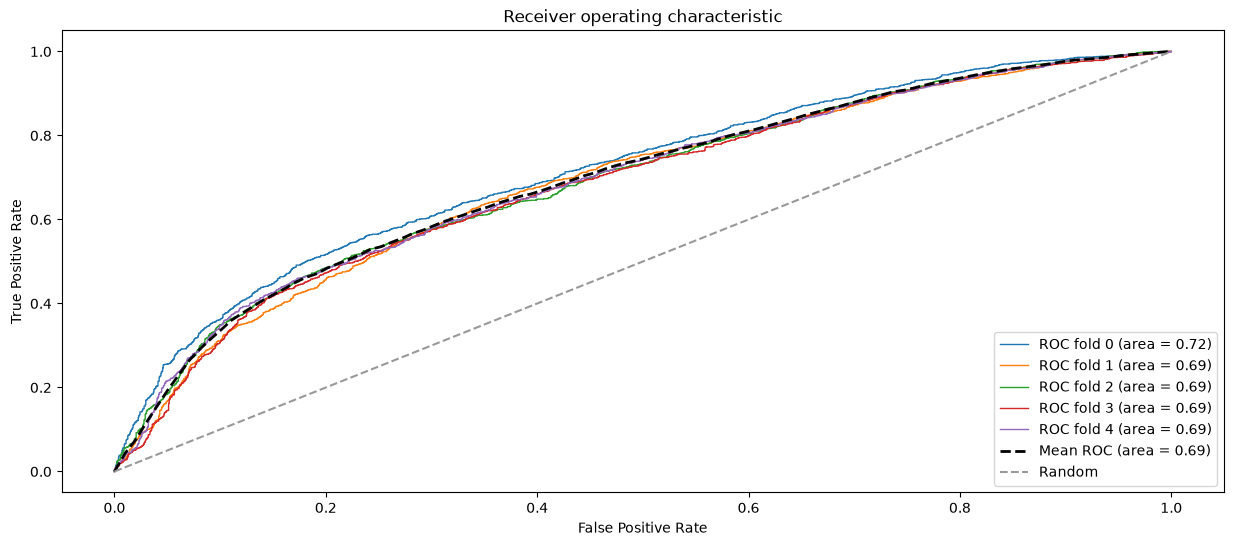

Decision Tree:


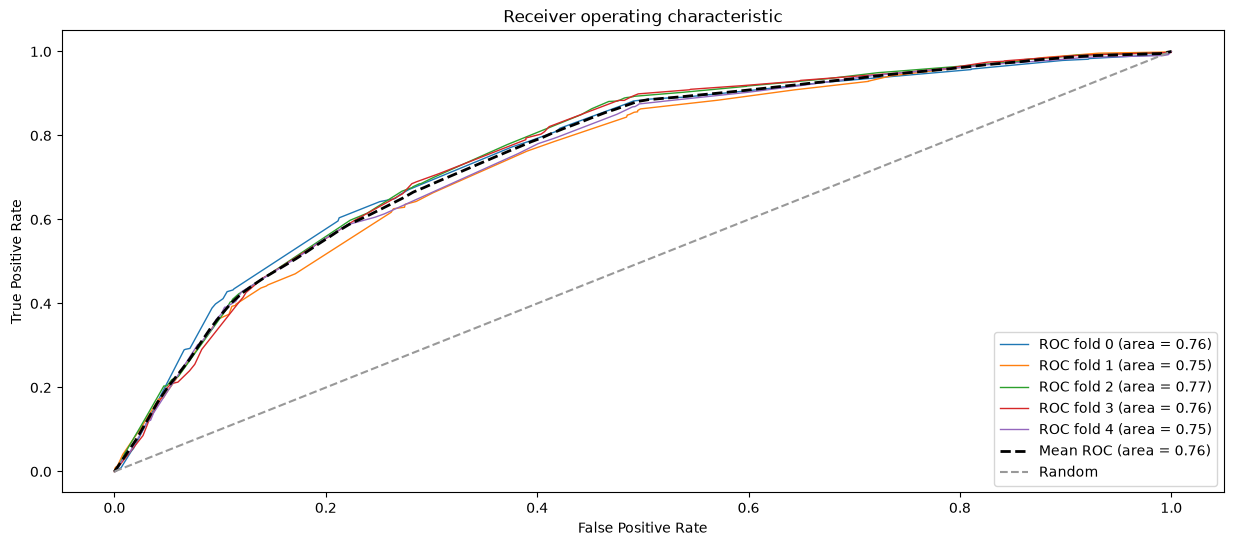

Random Forest:


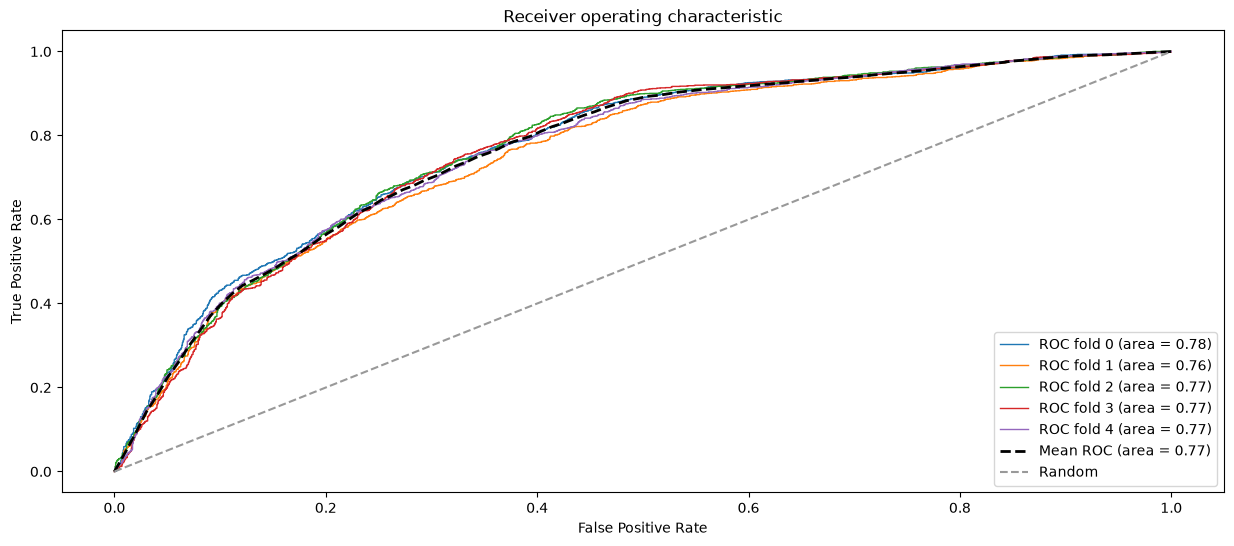

Gradient Boosting Classifier:


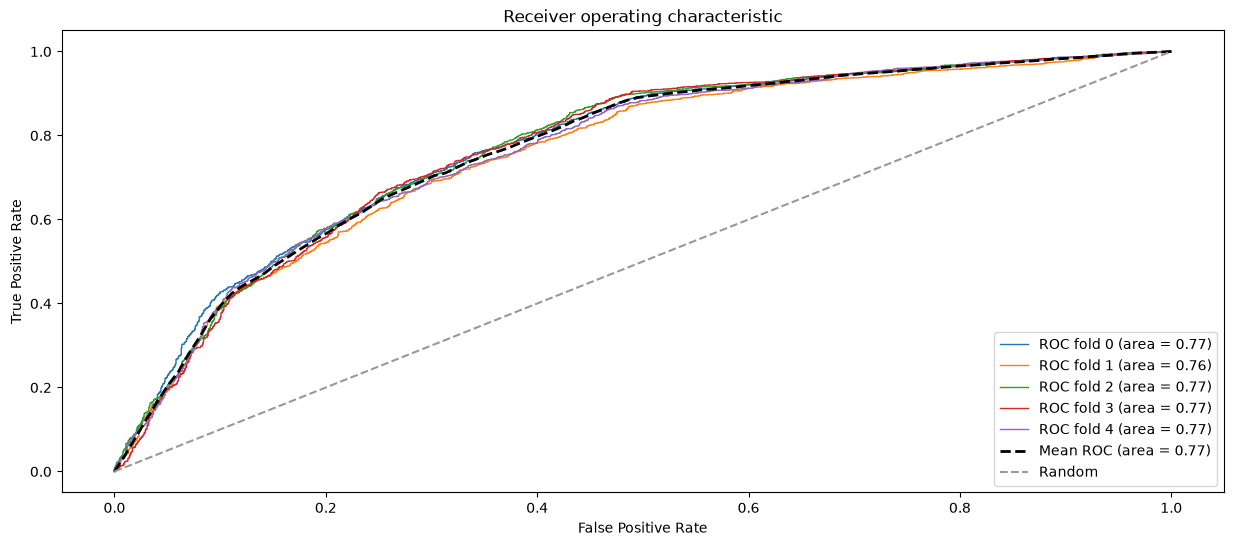

In [13]:
from sklearn.metrics import roc_curve, auc

def plot_roc(X, y, clf_class, **kwargs):
    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    y_prob = np.zeros((len(y), 2))
    mean_tpr = 0.0
    mean_fpr = np.linspace(0, 1, 100)

    fig, ax = plt.subplots(figsize=(15, 6))
    for i, (train_index, test_index) in enumerate(kf.split(X)):
        X_train, X_test = X[train_index], X[test_index]
        y_train = y[train_index]
        clf = clf_class(**kwargs)
        clf.fit(X_train, y_train)
        y_prob[test_index] = clf.predict_proba(X_test)
        fpr, tpr, _ = roc_curve(y[test_index], y_prob[test_index, 1])
        mean_tpr += np.interp(mean_fpr, fpr, tpr)
        mean_tpr[0] = 0.0
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=1, label='ROC fold %d (area = %0.2f)' % (i, roc_auc))

    mean_tpr /= kf.get_n_splits()
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    ax.plot(mean_fpr, mean_tpr, 'k--', label='Mean ROC (area = %0.2f)' % mean_auc, lw=2)

    ax.plot([0, 1], [0, 1], '--', color=(0.6, 0.6, 0.6), label='Random')
    ax.set_xlim([-0.05, 1.05])
    ax.set_ylim([-0.05, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('Receiver operating characteristic')
    ax.legend(loc="lower right")
    plt.show()

print("Logistic Regression:")
plot_roc(X, y, LR, max_iter=1000)

print("Decision Tree:")
plot_roc(X, y, DT, max_depth=6, random_state=RANDOM_STATE)

print("Random Forest:")
plot_roc(X, y, RF, n_estimators=200, max_depth=8, random_state=RANDOM_STATE)

print("Gradient Boosting Classifier:")
plot_roc(X, y, GBC, random_state=RANDOM_STATE)

### Feature importance

Now that we know roughly how accurate each model is, it's worth looking at which features are actually driving those predictions. A random forest builds its trees by repeatedly splitting on whichever feature reduces impurity the most, so averaging that reduction across all the trees gives a ranking of what the forest found useful.

Feature ranking:
1. house (0.300990)
2. overage (0.189550)
3. income (0.125272)
4. over_15min (0.114818)
5. leftover (0.090434)
6. init_payment (0.077597)
7. call_duration (0.055695)
8. change_plan (0.012356)
9. usage_level (0.012295)
10. satisfaction (0.011246)
11. college (0.005323)
12. college_missing (0.004424)


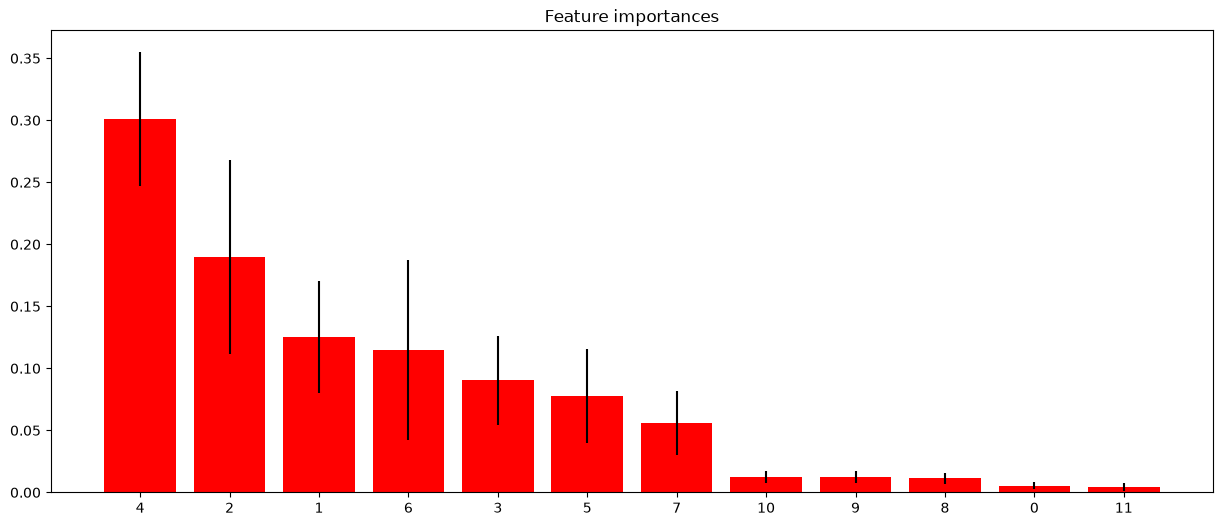

In [14]:
train_index, test_index = train_test_split(
    churn_df.index, test_size=0.25, random_state=RANDOM_STATE
)

forest = RF(n_estimators=200, max_depth=8, random_state=RANDOM_STATE)
forest_fit = forest.fit(X[train_index], y[train_index])
forest_predictions = forest_fit.predict(X[test_index])

importances = forest_fit.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest_fit.estimators_], axis=0)
indices = np.argsort(importances)[::-1]

print("Feature ranking:")
for f in range(len(features)):
    print("%d. %s (%f)" % (f + 1, features[indices[f]], importances[indices[f]]))

fig, ax = plt.subplots(figsize=(15, 6))
ax.set_title("Feature importances")
ax.bar(range(len(features)), importances[indices], yerr=std[indices], color="r", align="center")
ax.set_xticks(range(len(features)))
ax.set_xticklabels(indices)
ax.set_xlim([-1, len(features)])
plt.show()

`house`, `overage` and `income` top the list, with `satisfaction` and `change_plan` near the bottom -- the opposite order from what the raw churn rates in the EDA section suggested. That's the usual catch with this kind of importance score: continuous columns with many possible split points (`house`, `income`) tend to get inflated importance compared to the 5-level ordinal columns, regardless of how predictive they really are. Worth keeping in mind before treating this ranking as the final word on what drives churn.

### Thinking in probabilities

A flat "will churn / won't churn" label throws away information. There's a real difference between a customer who's 55% likely to churn and one who's 95% likely to, even though both get the same label at a 50% cutoff -- and that difference matters when deciding who the retention team calls first. `predict_proba` gives us that instead of a hard class, with only a couple of lines changed from `run_cv` above.

In [15]:
def run_prob_cv(X, y, clf_class, **kwargs):
    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    y_prob = np.zeros((len(y), 2))
    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train = y[train_index]
        clf = clf_class(**kwargs)
        clf.fit(X_train, y_train)
        y_prob[test_index] = clf.predict_proba(X_test)
    return y_prob

The model isn't making one prediction, it's making thousands. So for every time it says "70% chance of churn," we can go back and check how often that actually happened. Rounding random forest's predicted probabilities to the nearest 10% makes this easy to read off.

In [16]:
pred_prob = run_prob_cv(X, y, RF, n_estimators=200, max_depth=8, random_state=RANDOM_STATE)
pred_churn = np.round(pred_prob[:, 1], 1)
is_churn = y == 1

counts = pd.Series(pred_churn).value_counts()
counts

0.5    3880
0.2    3816
0.8    3337
0.6    2748
0.3    1384
0.7    1240
0.4    1172
0.1     210
0.9      12
Name: count, dtype: int64

In [17]:
from collections import defaultdict

true_prob = defaultdict(float)
for prob in counts.index:
    true_prob[prob] = np.mean(is_churn[pred_churn == prob])
true_prob = pd.Series(true_prob)

calibration_table = pd.concat([counts, true_prob], axis=1).reset_index()
calibration_table.columns = ['pred_prob', 'count', 'true_prob']
calibration_table = calibration_table.sort_values('pred_prob').reset_index(drop=True)
calibration_table

,pred_prob,count,true_prob
0,0.1,210,0.100000
1,0.2,3816,0.169549
2,0.3,1384,0.195809
3,0.4,1172,0.425768
4,0.5,3880,0.524227
5,0.6,2748,0.609534
6,0.7,1240,0.756452
7,0.8,3337,0.804315
8,0.9,12,0.833333


Reading down that table: the higher the probability random forest assigns, the higher the actual churn rate turns out to be, which is exactly what a well-behaved probability estimate should look like -- the group predicted at 90%+ churns far more often than the group predicted at 10%.

Two more useful numbers here are calibration and discrimination. Calibration asks whether predicted probabilities match observed frequencies (predict 60%, see 60%). Discrimination asks whether the model spreads customers out across different risk levels at all, rather than assigning everyone roughly the same probability.

In [18]:
def calibration(prob, outcome, bins=calibration_table['pred_prob']):
    cal = 0.0
    for b in bins:
        mask = prob == b
        if mask.sum() == 0:
            continue
        cal += mask.mean() * (outcome[mask].mean() - b) ** 2
    return cal

def discrimination(prob, outcome, bins=calibration_table['pred_prob']):
    base_rate = outcome.mean()
    disc = 0.0
    for b in bins:
        mask = prob == b
        if mask.sum() == 0:
            continue
        disc += mask.mean() * (outcome[mask].mean() - base_rate) ** 2
    return disc

print("Calibration Error: %.4f" % calibration(pred_churn, is_churn))
print("Discrimination:    %.4f" % discrimination(pred_churn, is_churn))
print("Lower calibration is better, higher discrimination is better.")

Calibration Error: 0.0015
Discrimination:    0.0568
Lower calibration is better, higher discrimination is better.


Discrimination being clearly larger than the calibration error means random forest is doing real work here: it isn't just handing back the overall churn rate for everyone, it's meaningfully separating high-risk customers from low-risk ones, and its risk estimates roughly track reality.